# **1. Mengunduh dan Mengekstrak File ZIP Dataset**

In [1]:
# 1. SSL Certificate Fix (for macOS)
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Install libraries
!pip install -q split-folders gdown pillow-heif

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings

import gdown
import zipfile
import glob

file_id = '1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT'
url = f'https://drive.google.com/uc?id={file_id}'

output_zip = './dataset_raw.zip'
extract_dir = './dataset_raw'

print("=========================================================")
print("--- MENGUNDUH FILE ZIP DATASET DARI GOOGLE DRIVE ---")
print("=========================================================")

gdown.download(url, output_zip, quiet=False)

print("\n=========================================================")
print("--- MEMULAI PROSES EKSTRAKSI FILE ZIP ---")
print("=========================================================")

# Mengekstrak file zip ke folder lokal
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Ekstraksi selesai!")

# Cek isi folder hasil ekstraksi untuk memastikan folder 'mobil' dan 'motor' aman
print("\nDaftar direktori yang berhasil diekstrak:")
for root, dirs, files in os.walk(extract_dir):
    if len(dirs) > 0:
        print(f"Lokasi: {root} -> Berisi folder: {dirs}")

--- MENGUNDUH FILE ZIP DATASET DARI GOOGLE DRIVE ---


Downloading...
From (original): https://drive.google.com/uc?id=1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT
From (redirected): https://drive.google.com/uc?id=1VHA-PIYJdG0wGfNRYIfTwQSpvaEhysrT&confirm=t&uuid=0a2e4ded-0f94-49a3-9fb9-e0a7ca5f365e
To: /Users/eugeniagraselamaia/Documents/uni/sem6/deep learning/projectUAS/dataset_raw.zip
100%|██████████| 43.4M/43.4M [00:06<00:00, 6.70MB/s]



--- MEMULAI PROSES EKSTRAKSI FILE ZIP ---
Ekstraksi selesai!

Daftar direktori yang berhasil diekstrak:
Lokasi: ./dataset_raw -> Berisi folder: ['mobil vs motor']
Lokasi: ./dataset_raw/mobil vs motor -> Berisi folder: ['motor', 'mobil']


# **Cell 2: Standardisasi Format Gambar & Rename Berurutan**

In [2]:
from PIL import Image
import pillow_heif
import os

# Daftarkan penanganan format HEIF/HEIC ke Pillow
pillow_heif.register_heif_opener()

# Path folder mentah hasil unduhan dari Drive
base_dataset_dir = './dataset_raw'
subfolders = [os.path.join(base_dataset_dir, f) for f in os.listdir(base_dataset_dir) if os.path.isdir(os.path.join(base_dataset_dir, f))]

# Deteksi jika folder terbungkus (nested folder) saat diekstrak
if len(subfolders) == 1 and ('mobil' not in os.listdir(base_dataset_dir)):
    source_dir = subfolders[0]
else:
    source_dir = base_dataset_dir

# Buat folder 'gabungan' murni (flat tanpa subfolder mobil/motor di dalamnya)
output_gabungan_dir = './gabungan'
os.makedirs(output_gabungan_dir, exist_ok=True)

print(f"✓ Folder tujuan sukses dibuat: {output_gabungan_dir}")

# Ekstensi gambar yang valid untuk diproses
valid_extensions = ('.heic', '.heif', '.png', '.webp', '.jpeg', '.jpg', '.PNG', '.JPEG', '.JPG', '.HEIC')

# Fungsi untuk memproses kloning, konversi, dan penamaan ulang langsung ke satu folder
def process_and_rename_flat(class_name, target_save_dir):
    source_class_dir = os.path.join(source_dir, class_name)
    
    if not os.path.exists(source_class_dir):
        print(f"⚠ Peringatan: Folder asal untuk kelas '{class_name}' tidak ditemukan.")
        return 0
    
    counter = 1
    files = os.listdir(source_class_dir)
    
    for file in files:
        file_path = os.path.join(source_class_dir, file)
        
        if os.path.isfile(file_path):
            _, file_ext = os.path.splitext(file)
            
            if file_ext.lower() in valid_extensions:
                try:
                    img = Image.open(file_path)
                    
                    # Pastikan diconvert ke RGB murni agar format warna seragam
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # Berkas disimpan di ./gabungan/mobil1.jpg atau ./gabungan/motor1.jpg
                    new_filename = f"{class_name}{counter}.jpg"
                    new_file_path = os.path.join(target_save_dir, new_filename)
                    
                    img.save(new_file_path, 'JPEG', quality=90)
                    counter += 1
                    
                except Exception as e:
                    print(f"⚠ Gagal memproses file {file} di kelas {class_name}: {str(e)}")
                    
    return counter - 1

# Eksekusi proses untuk kedua kelas kendaraan
print("\n--- Memulai Standardisasi & Rename Gambar ---")
total_mobil = process_and_rename_flat('mobil', output_gabungan_dir)
print(f"✓ Sukses mengonversi dan me-rename {total_mobil} gambar mobil -> dimasukkan ke folder gabungan/")

total_motor = process_and_rename_flat('motor', output_gabungan_dir)
print(f"✓ Sukses mengonversi dan me-rename {total_motor} gambar motor -> dimasukkan ke folder gabungan/")

print(f"\nTotal keseluruhan data di folder gabungan murni: {len(os.listdir(output_gabungan_dir))} file .jpg")

✓ Folder tujuan sukses dibuat: ./gabungan

--- Memulai Standardisasi & Rename Gambar ---
✓ Sukses mengonversi dan me-rename 55 gambar mobil -> dimasukkan ke folder gabungan/
✓ Sukses mengonversi dan me-rename 83 gambar motor -> dimasukkan ke folder gabungan/

Total keseluruhan data di folder gabungan murni: 1200 file .jpg


# **Proses Augmentasi Fisik (Offline) ke Folder Gabungan**

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from PIL import Image

# Tentukan target jumlah data fisik akhir yang kamu inginkan per kelas
# Menambah data fisik secara signifikan membantu CNN Baseline keluar dari zona underfitting
TARGET_PER_KELAS = 600 

folder_gabungan = './gabungan'
all_files = os.listdir(folder_gabungan)

# Definisikan generator augmentasi internal khusus untuk memproduksi file fisik
offline_dg = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

print("=========================================================")
print("      PROSES GENERATE AUGMENTASI FISIK (OFFLINE)         ")
print("=========================================================")

for kelas in ['mobil', 'motor']:
    files_kelas = [f for f in all_files if f.startswith(kelas)]
    jumlah_sekarang = len(files_kelas)
    
    if jumlah_sekarang < TARGET_PER_KELAS:
        kekurangan = TARGET_PER_KELAS - jumlah_sekarang
        print(f"➔ Kelas {kelas.upper()}: Jumlah asli {jumlah_sekarang} file. Menambah {kekurangan} file augmentasi baru...")
        
        counter_save = jumlah_sekarang + 1
        
        for i in range(kekurangan):
            # Pilih 1 gambar asli secara acak sebagai core objek cetakan
            file_pilihan = np.random.choice(files_kelas)
            img = load_img(os.path.join(folder_gabungan, file_pilihan), target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)
            
            # Ambil 1 hasil modifikasi acak dari generator
            iterator = offline_dg.flow(x, batch_size=1)
            batch = next(iterator)
            img_hasil = batch[0]
            
            # Beri nama kelanjutan (misal: mobil201.jpg, mobil202.jpg dst)
            nama_file_baru = f"{kelas}{counter_save}.jpg"
            path_save = os.path.join(folder_gabungan, nama_file_baru)
            
            # Simpan secara fisik ke folder gabungan
            img_save_ready = img_hasil.astype(np.uint8)
            Image.fromarray(img_save_ready).save(path_save, 'JPEG', quality=90)
            
            counter_save += 1
    else:
        print(f"✓ Kelas {kelas.upper()} sudah memiliki {jumlah_sekarang} gambar (melebihi target). Tidak dilakukan augmentasi fisik.")

print(f"\n✓ SELESAI! Sekarang total file fisik di folder gabungan menjadi: {len(os.listdir(folder_gabungan))} gambar.")

2026-06-08 13:29:04.917254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


      PROSES GENERATE AUGMENTASI FISIK (OFFLINE)         
➔ Kelas MOBIL: Jumlah asli 55 file. Menambah 545 file augmentasi baru...
➔ Kelas MOTOR: Jumlah asli 83 file. Menambah 517 file augmentasi baru...

✓ SELESAI! Sekarang total file fisik di folder gabungan menjadi: 1200 gambar.


# **2b: Proses Stratified Split Manual (70:15:15)**

In [3]:
import shutil
from sklearn.model_selection import train_test_split

# 1. Kumpulkan semua file dan labelnya dari folder gabungan
all_files = os.listdir(output_gabungan_dir)
files_list = []
labels_list = []

for f in all_files:
    if f.startswith('mobil'):
        files_list.append(f)
        labels_list.append('mobil')
    elif f.startswith('motor'):
        files_list.append(f)
        labels_list.append('motor')

# 2. Proses Pembagian Data (70% Train, 15% Val, 15% Test)
# Pisahkan Train (70%) dan Sisa (30%) terlebih dahulu
X_train, X_temp, y_train, y_temp = train_test_split(
    files_list, labels_list, test_size=0.30, random_state=1008, stratify=labels_list
)

# Pisahkan Sisa (30%) menjadi Val (15%) dan Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=1008, stratify=y_temp
)

# 3. Buat direktori tujuan split akhir untuk ImageDataGenerator
output_split_folder = './dataset_split'
for split in ['train', 'val', 'test']:
    for class_label in ['mobil', 'motor']:
        os.makedirs(os.path.join(output_split_folder, split, class_label), exist_ok=True)

# Fungsi bantu untuk menyalin file ke tempat split masing-masing
def copy_split_files(files, split_name):
    for f in files:
        label = 'mobil' if f.startswith('mobil') else 'motor'
        src = os.path.join(output_gabungan_dir, f)
        dst = os.path.join(output_split_folder, split_name, label, f)
        shutil.copy(src, dst)

# Eksekusi penyalinan file
copy_split_files(X_train, 'train')
copy_split_files(X_val, 'val')
copy_split_files(X_test, 'test')

print("=========================================================================")
print("✓ DATASET BERHASIL DI-SPLIT STRATIFIED DARI FOLDER GABUNGAN MURNI!")
print("=========================================================================\n")

# Verifikasi jumlah data akhir untuk validasi bab metodologi penelitian kamu
for split in ['train', 'val', 'test']:
    print(f"--- Subset {split.upper()} ---")
    for kelas in ['mobil', 'motor']:
        path_cek = os.path.join(output_split_folder, split, kelas)
        print(f"Jumlah file di kelas '{kelas}': {len(os.listdir(path_cek))} gambar (.jpg)")

✓ DATASET BERHASIL DI-SPLIT STRATIFIED DARI FOLDER GABUNGAN MURNI!

--- Subset TRAIN ---
Jumlah file di kelas 'mobil': 420 gambar (.jpg)
Jumlah file di kelas 'motor': 420 gambar (.jpg)
--- Subset VAL ---
Jumlah file di kelas 'mobil': 90 gambar (.jpg)
Jumlah file di kelas 'motor': 90 gambar (.jpg)
--- Subset TEST ---
Jumlah file di kelas 'mobil': 90 gambar (.jpg)
Jumlah file di kelas 'motor': 90 gambar (.jpg)


# **3: Preprocessing & Data Augmentation Pipeline**

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# KINI HANYA RESCALE (Normalisasi Skala) karena augmentasi variasi objek sudah terkunci permanen di folder fisik
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Loading Data Training ---")
train_generator = train_datagen.flow_from_directory(
    './dataset_split/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\n--- Loading Data Validasi ---")
val_generator = val_test_datagen.flow_from_directory(
    './dataset_split/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n--- Loading Data Testing ---")
test_generator = val_test_datagen.flow_from_directory(
    './dataset_split/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nIndeks Kelas Terdeteksi: {train_generator.class_indices}")

--- Loading Data Training ---
Found 840 images belonging to 2 classes.

--- Loading Data Validasi ---
Found 180 images belonging to 2 classes.

--- Loading Data Testing ---
Found 180 images belonging to 2 classes.

Indeks Kelas Terdeteksi: {'mobil': 0, 'motor': 1}


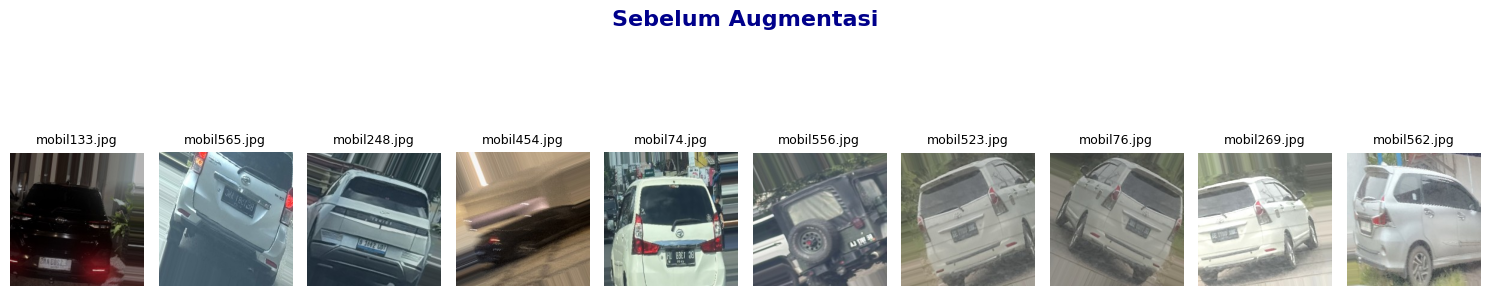

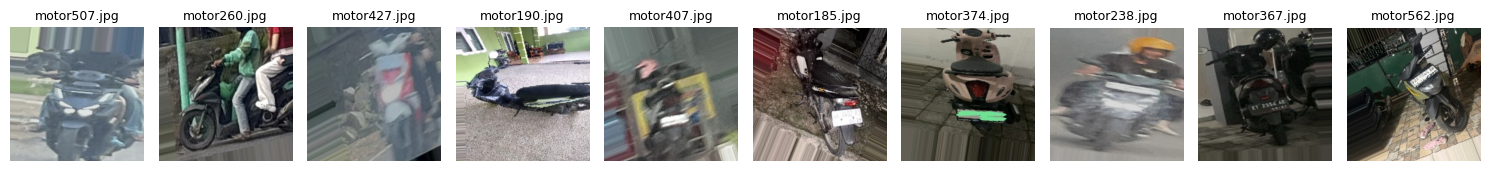

In [7]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os
import random

folder_gabungan = './gabungan'
all_files = os.listdir(folder_gabungan)

# Filter file berdasarkan nama kelas
mobil_files = [f for f in all_files if f.startswith('mobil')]
motor_files = [f for f in all_files if f.startswith('motor')]

# Ambil masing-masing 10 sampel secara acak
sampel_mobil = random.sample(mobil_files, min(10, len(mobil_files)))
sampel_motor = random.sample(motor_files, min(10, len(motor_files)))

# Plot 10 Sampel Mobil Asli
plt.figure(figsize=(15, 4))
plt.suptitle("Sebelum Augmentasi", fontsize=16, fontweight='bold', color='darkblue')
for i, file_name in enumerate(sampel_mobil):
    plt.subplot(1, 10, i + 1)
    img = load_img(os.path.join(folder_gabungan, file_name), target_size=(224, 224))
    plt.imshow(img)
    plt.title(file_name, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Plot 10 Sampel Motor Asli
plt.figure(figsize=(15, 4))
for i, file_name in enumerate(sampel_motor):
    plt.subplot(1, 10, i + 1)
    img = load_img(os.path.join(folder_gabungan, file_name), target_size=(224, 224))
    plt.imshow(img)
    plt.title(file_name, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

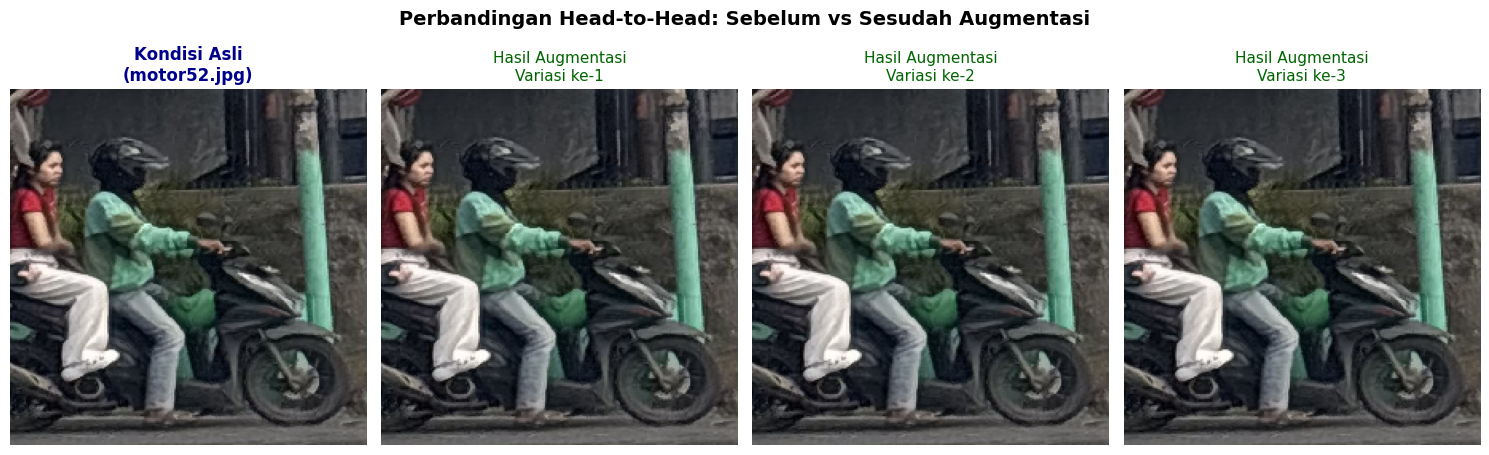

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import random
import os

folder_gabungan = './gabungan'
semua_gambar = os.listdir(folder_gabungan)
gambar_sampel = random.choice(semua_gambar)
path_gambar_sampel = os.path.join(folder_gabungan, gambar_sampel)

# Load gambar asli
img_asli = load_img(path_gambar_sampel, target_size=(224, 224))
img_array = img_to_array(img_asli)  
img_array_expanded = np.expand_dims(img_array, axis=0) 

# Generate 3 variasi teknik augmentasi secara acak
augmented_images = []
iterator = train_datagen.flow(img_array_expanded, batch_size=1)

for _ in range(3):
    batch = next(iterator)
    image = batch[0] 
    augmented_images.append(image)

# Plot Perbandingan
plt.figure(figsize=(15, 5))
plt.suptitle("Perbandingan Head-to-Head: Sebelum vs Sesudah Augmentasi", fontsize=14, fontweight='bold')

# Kolom 1: Asli
plt.subplot(1, 4, 1)
plt.imshow(img_asli)
plt.title(f"Kondisi Asli\n({gambar_sampel})", fontsize=12, color='darkblue', fontweight='bold')
plt.axis('off')

# Kolom 2-4: Hasil Transformasi Augmentasi
for i, img_aug in enumerate(augmented_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(img_aug)
    plt.title(f"Hasil Augmentasi\nVariasi ke-{i+1}", fontsize=11, color='darkgreen')
    plt.axis('off')

plt.tight_layout()
plt.show()

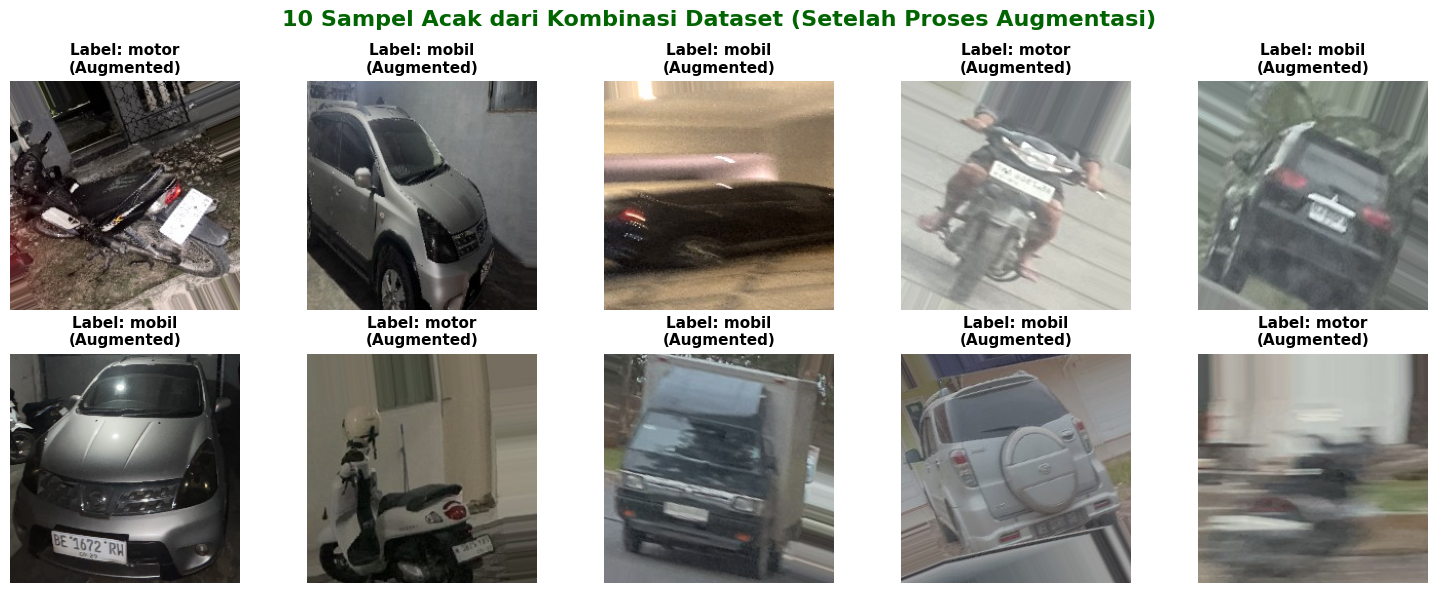

In [9]:
import matplotlib.pyplot as plt

# Mengambil satu batch data acak dari train_generator
# Karena batch_size = 32, kita bisa mengambil 10 gambar pertama dari batch tersebut
images_batch, labels_batch = next(train_generator)

# Ambil pemetaan indeks kelas (0 untuk kelas pertama, 1 untuk kelas kedua)
labels_map = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(15, 6))
plt.suptitle("10 Sampel Acak dari Kombinasi Dataset (Setelah Proses Augmentasi)", fontsize=16, fontweight='bold', color='darkgreen')

# Menampilkan 10 gambar hasil transformasi augmentasi secara berjejer
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_batch[i])
    
    # Deteksi label biner asli dari gambar tersebut
    class_label = labels_map[int(labels_batch[i])]
    plt.title(f"Label: {class_label}\n(Augmented)", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# **4: Model Factory (Definisi 3 Arsitektur Jaringan)**

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50

# --- MODEL 1: CNN BASELINE (Membangun dari Nol) ---
def build_baseline_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),                    
        layers.Dense(1, activation='sigmoid')   
    ])
    return model

# --- MODEL 2: MOBILENETV2 (Transfer Learning) ---
def build_mobilenet_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model, base_model

# --- MODEL 3: RESNET50 (Transfer Learning) ---
def build_resnet_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    return model, base_model

# **5: Konfigurasi Callbacks Medis & Akademis**

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    return [
        # Menghentikan latihan jika val_loss tidak membaik selama 5 epoch berturut-turut
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        
        # Hanya menyimpan berkas model (.h5) yang menghasilkan val_loss terkecil (Paling Bagus)
        ModelCheckpoint(filepath=f'{model_name}_best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
    ]

# **Cell 6: Eksperimen Pelatihan - Model 1: CNN Baseline**

In [12]:
baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("     MEMULAI TRAINING: CNN BASELINE       ")
print("==========================================")

history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=get_callbacks('cnn_baseline')
)

     MEMULAI TRAINING: CNN BASELINE       
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5325 - loss: 0.8713
Epoch 1: val_loss improved from None to 0.66687, saving model to cnn_baseline_best_model.h5



Epoch 1: finished saving model to cnn_baseline_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 0.5774 - loss: 0.7351 - val_accuracy: 0.6500 - val_loss: 0.6669
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6815 - loss: 0.6003
Epoch 2: val_loss improved from 0.66687 to 0.46348, saving model to cnn_baseline_best_model.h5



Epoch 2: finished saving model to cnn_baseline_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.7060 - loss: 0.5693 - val_accuracy: 0.8167 - val_loss: 0.4635
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8081 - loss: 0.4561
Epoch 3: val_loss improved from 0.46348 to 0.44333, saving model to cnn_baseline_best_model.h5



Epoch 3: finished saving model to cnn_baseline_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.7929 - loss: 0.4641 - val_accuracy: 0.8222 - val_loss: 0.4433
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8544 - loss: 0.4181
Epoch 4: val_loss improved from 0.44333 to 0.43224, saving model to cnn_baseline_best_model.h5



Epoch 4: finished saving model to cnn_baseline_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8298 - loss: 0.4250 - val_accuracy: 0.8667 - val_loss: 0.4322
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8703 - loss: 0.3788
Epoch 5: val_loss improved from 0.43224 to 0.38228, saving model to cnn_baseline_best_model.h5



Epoch 5: finished saving model to cnn_baseline_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 166s 5s/step - accuracy: 0.8381 - loss: 0.3868 - val_accuracy: 0.8444 - val_loss: 0.3823
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8694 - loss: 0.3119
Epoch 6: val_loss did not improve from 0.38228
27/27 ━━━━━━━━━━━━━━━━━━━━ 120s 5s/step - accuracy: 0.8738 - loss: 0.3180 - val_accuracy: 0.8500 - val_loss: 0.3941
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9156 - loss: 0.2395
Epoch 7: val_loss did not improve from 0.38228
27/27 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.9179 - loss: 0.2202 - val_accuracy: 0.8444 - val_loss: 0.3995
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9094 - loss: 0.2058
Epoch 8: val_loss did not improve from 0.38228
27/27 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9083 - loss: 0.2146 - val_accuracy: 0.8500 - val_loss: 0.4299
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9252 - loss: 0.1759
E

# **7: Eksperimen Pelatihan - Model 2: MobileNetV2 (Skema 2 Tahap)**

In [ ]:
mobilenet_model, mobilenet_base = build_mobilenet_model()

# ----------- TAHAP 1: FEATURE EXTRACTION -----------
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("   MOBILENETV2 - TAHAP 1: FEATURE EXTRACT  ")
print("==========================================")
_ = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# ----------- TAHAP 2: FINE-TUNING -----------
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n==========================================")
print("     MOBILENETV2 - TAHAP 2: FINE-TUNING    ")
print("==========================================")
history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=get_callbacks('mobilenetv2')
)

   MOBILENETV2 - TAHAP 1: FEATURE EXTRACT  
Epoch 1/10
 4/28 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5990 - loss: 0.6853

2026-05-27 05:54:28.307007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:28.443690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:28.580379: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8360 - loss: 0.3581

2026-05-27 05:54:46.537765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 05:54:46.674592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8389 - loss: 0.3529 - val_accuracy: 0.9850 - val_loss: 0.0425
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9828 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0240
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.9903 - loss: 0.0343 - val_accuracy: 0.9950 - val_loss: 0.0293
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9921 - loss: 0.0383 - val_accuracy: 0.9950 - val_loss: 0.0210
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9847 - loss: 0.0380 - val_accuracy: 0.9950 - val_loss: 0.0166
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9906 - loss: 0.0230 - val_accuracy: 0.9950 - val_loss: 0.0133
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9842 - loss: 0.0309 - val_accuracy: 0.9950 - val_loss: 0.0144
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9950 - val_lo

...

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9965 - loss: 0.0063 - val_accuracy: 0.9900 - val_loss: 0.0174
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9970 - loss: 0.0066
Epoch 8: val_loss improved from 0.01737 to 0.01414, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9970 - loss: 0.0068 - val_accuracy: 0.9900 - val_loss: 0.0141
Epoch 9/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9976 - loss: 0.0057
Epoch 9: val_loss improved from 0.01414 to 0.01392, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.9975 - loss: 0.0059 - val_accuracy: 0.9950 - val_loss: 0.0139
Epoch 10/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9969 - loss: 0.0056
Epoch 10: val_loss improved from 0.01392 to 0.01254, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.9969 - loss: 0.0056 - val_accuracy: 0.9900 - val_loss: 0.0125
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9978 - loss: 0.0041
Epoch 11: val_loss improved from 0.01254 to 0.01146, saving model to mobilenetv2_best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9978 - loss: 0.0041 - val_accuracy: 0.9950 - val_loss: 0.0115
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9981 - loss: 0.0058
Epoch 12: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9900 - val_loss: 0.0171
Epoch 13/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9967 - loss: 0.0069
Epoch 13: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.9967 - loss: 0.0069 - val_accuracy: 0.9950 - val_loss: 0.0125
Epoch 14/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9958 - loss: 0.0093
Epoch 14: val_loss did not improve from 0.01146
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.9958 - loss: 0.0093 - val_accuracy: 0.9850 - val_loss: 0.0212
Epoch 15/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.0040
Epoch 15: val_loss did not improve from 0

# **8:Eksperimen Pelatihan - Model 3: ResNet50 (Skema 2 Tahap)**

In [9]:
resnet_model, resnet_base = build_resnet_model()

# ----------- TAHAP 1: FEATURE EXTRACTION -----------
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("==========================================")
print("     RESNET50 - TAHAP 1: FEATURE EXTRACT   ")
print("==========================================")
_ = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# ----------- TAHAP 2: FINE-TUNING -----------
resnet_base.trainable = True
for layer in resnet_base.layers:
    if 'conv5_' not in layer.name and 'res5' not in layer.name:
        layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n==========================================")
print("       RESNET50 - TAHAP 2: FINE-TUNING     ")
print("==========================================")
history_resnet = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=get_callbacks('resnet50')
)

     RESNET50 - TAHAP 1: FEATURE EXTRACT   
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.5179 - loss: 0.7821 - val_accuracy: 0.5056 - val_loss: 0.6845
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.5238 - loss: 0.7146 - val_accuracy: 0.5500 - val_loss: 0.6700
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.5286 - loss: 0.6912 - val_accuracy: 0.5556 - val_loss: 0.6631
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.5833 - loss: 0.6723 - val_accuracy: 0.5222 - val_loss: 0.6675
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.5321 - loss: 0.6929 - val_accuracy: 0.7167 - val_loss: 0.6497
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.5881 - loss: 0.6745 - val_accuracy: 0.7000 - val_loss: 0.6461
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.6143 - loss: 0.6588 - val_accuracy: 0.5111 - val_loss: 0.6887
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 484s 18s/step - accuracy: 0.5


Epoch 1: finished saving model to resnet50_best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.6881 - loss: 0.5834 - val_accuracy: 0.5500 - val_loss: 0.6591
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8067 - loss: 0.4362
Epoch 2: val_loss did not improve from 0.65906
27/27 ━━━━━━━━━━━━━━━━━━━━ 184s 7s/step - accuracy: 0.8298 - loss: 0.3881 - val_accuracy: 0.5333 - val_loss: 0.7283
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8749 - loss: 0.3007
Epoch 3: val_loss did not improve from 0.65906
27/27 ━━━━━━━━━━━━━━━━━━━━ 181s 7s/step - accuracy: 0.8881 - loss: 0.2856 - val_accuracy: 0.5222 - val_loss: 0.7849
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9598 - loss: 0.1826
Epoch 4: val_loss did not improve from 0.65906
27/27 ━━━━━━━━━━━━━━━━━━━━ 188s 7s/step - accuracy: 0.9571 - loss: 0.1766 - val_accuracy: 0.5111 - val_loss: 0.7984
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9725 - loss: 0.1216
Epoch

# **9:Visualisasi Kurva Evaluasi Training (Akurasi & Loss)**

=== Evaluasi Visual CNN Baseline ===
⚠ CNN Baseline training history not available. Please train the model first.

=== Evaluasi Visual MobileNetV2 (Fine-tuning) ===
⚠ MobileNetV2 training history not available. Please train the model first.

=== Evaluasi Visual ResNet50 (Fine-tuning) ===


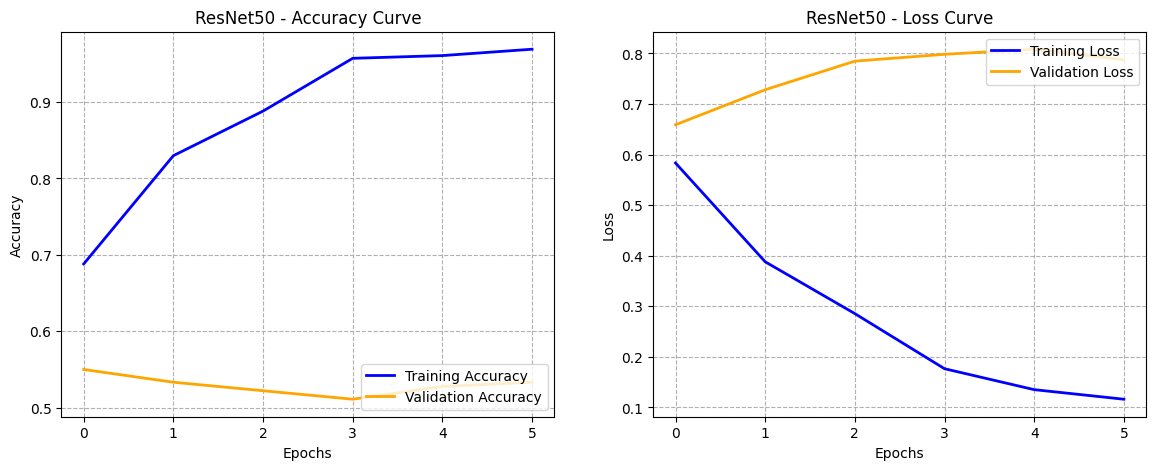

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name):
    if history is None:
        print(f"⚠ {model_name} training history not available. Please train the model first.")
        return
        
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--')

    plt.show()

# Safely plot training histories with error handling
print("=== Evaluasi Visual CNN Baseline ===")
plot_training_history(globals().get('history_baseline'), "CNN Baseline")

print("\n=== Evaluasi Visual MobileNetV2 (Fine-tuning) ===")
plot_training_history(globals().get('history_mobilenet'), "MobileNetV2")

print("\n=== Evaluasi Visual ResNet50 (Fine-tuning) ===")
plot_training_history(globals().get('history_resnet'), "ResNet50")

Evaluating trained models...

      EVALUASI AKHIR DATA TESTING: CNN Baseline        


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 745ms/step

--- Classification Performance Report ---
              precision    recall  f1-score   support

       mobil     0.7353    0.8333    0.7812        90
       motor     0.8077    0.7000    0.7500        90

    accuracy                         0.7667       180
   macro avg     0.7715    0.7667    0.7656       180
weighted avg     0.7715    0.7667    0.7656       180

--- Confusion Matrix ---


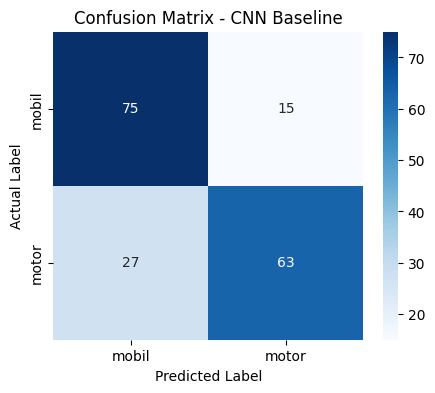

⚠ Model file not found: mobilenetv2_best_model.h5
   Please make sure to train the MobileNetV2 model first and save it.

      EVALUASI AKHIR DATA TESTING: ResNet50        


6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step

--- Classification Performance Report ---
              precision    recall  f1-score   support

       mobil     0.5466    0.9778    0.7012        90
       motor     0.8947    0.1889    0.3119        90

    accuracy                         0.5833       180
   macro avg     0.7207    0.5833    0.5066       180
weighted avg     0.7207    0.5833    0.5066       180

--- Confusion Matrix ---


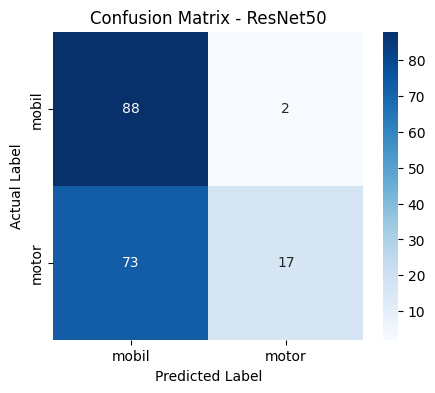

In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

def evaluate_best_model(model_path, model_name):
    # Check if model file exists
    if not os.path.exists(model_path):
        print(f"⚠ Model file not found: {model_path}")
        print(f"   Please make sure to train the {model_name} model first and save it.")
        return
    
    print(f"\n=======================================================")
    print(f"      EVALUASI AKHIR DATA TESTING: {model_name}        ")
    print(f"=======================================================")
    
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"⚠ Gagal memuat berkas {model_path}. Error: {str(e)}")
        return

    # Prediksi menggunakan data generator testing
    predictions = model.predict(test_generator, verbose=1)
    
    # Konversi nilai kontinu sigmoid (>0.5 -> 1, jika tidak -> 0)
    y_pred = np.where(predictions > 0.5, 1, 0).flatten()
    y_true = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    # 1. Cetak Laporan Hasil Klasifikasi (Precision, Recall, F1-Score)
    print("\n--- Classification Performance Report ---")
    print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

    # 2. Visualisasi Confusion Matrix menggunakan Seaborn Heatmap
    print("--- Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Jalankan fungsi pengujian untuk ketiga model terbaik
print("Evaluating trained models...")
evaluate_best_model('cnn_baseline_best_model.h5', 'CNN Baseline')
evaluate_best_model('mobilenetv2_best_model.h5', 'MobileNetV2')
evaluate_best_model('resnet50_best_model.h5', 'ResNet50')